# 6. Inference & Live Verification

Live Facial Verification using a webcam.

**Features:**
- Webcam Capture
- Real-time Face Verification
- Similarity Score Display
- Configurable Threshold

**Note:** This notebook can only be run locally (requires a webcam)

## 6.1 Import & Setup

In [30]:
import sys
from pathlib import Path
import numpy as np
import cv2
import tensorflow as tf
import keras
from src.models import L1Dist
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Project
sys.path.insert(0, str(Path.cwd().parent))
import config
from src import data, training, utils

print("✓ Imports successful")

✓ Imports successful


## 6.2 Loading Model

In [32]:
# Find latest checkpoint
best_checkpoint = training.get_best_checkpoint(str(config.CHECKPOINT_DIR)) or str(config.CHECKPOINT_DIR / "siamese_final.keras")

print(f"Loading model from: {best_checkpoint}\n")

try:
    siamese_model = keras.models.load_model(
        best_checkpoint,
        custom_objects={'L1Dist': L1Dist}
    )
    print("✓ Model loaded successfully")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    siamese_model = None

Loading model from: C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme\checkpoints\siamese_epoch_0010.keras

✓ Model loaded successfully


## 6.3 Webcam Setup & Calibration

In [33]:
if siamese_model is not None:
    print("\nStarting webcam...")
    print(f"\nConfiguration:")
    print(f"  Device: {config.WEBCAM_DEVICE}")
    print(f"  Crop Size: {config.WEBCAM_FRAME_SIZE}x{config.WEBCAM_FRAME_SIZE}")
    print(f"  Offset: ({config.WEBCAM_OFFSET_X}, {config.WEBCAM_OFFSET_Y})")
    print(f"  Verification Threshold: {config.VERIFICATION_THRESHOLD}")

    cap = cv2.VideoCapture(config.WEBCAM_DEVICE)

    if cap.isOpened():
        print("\n✓ Webcam connected successfully")
        # Load a frame for calibration
        ret, frame = cap.read()
        if ret:
            print(f"✓ First frame captured: {frame.shape}")
        cap.release()
    else:
        print("\n✗ Could not open webcam")
        print("   This notebook requires a local webcam for live verification")


Starting webcam...

Configuration:
  Device: 0
  Crop Size: 250x250
  Offset: (200, 120)
  Verification Threshold: 0.25

✓ Webcam connected successfully
✓ First frame captured: (480, 640, 3)


## 6.4 Anchor Image Choice

In [34]:
if siamese_model is not None:
    # Load anchor images
    anchor_paths = data.load_image_paths(str(config.ANCHOR_PATH))

    print(f"\nAnchor images available: {len(anchor_paths)}")
    print(f"\nSelecting a random anchor image...")

    if anchor_paths:
        import random
        anchor_path = random.choice(anchor_paths)
        anchor_img = data.load_image(anchor_path).numpy().astype(np.uint8)
        anchor_img_processed = data.preprocess_image(data.load_image(anchor_path)).numpy()

        print(f"✓ Anchor: {Path(anchor_path).name}")
        print(f"  Shape: {anchor_img.shape}")
    else:
        print("✗ No anchor images found")


Anchor images available: 400

Selecting a random anchor image...
✓ Anchor: 2c4ae40b-73c2-11f1-856f-ac198e6292dc.jpg
  Shape: (250, 250, 3)


## 6.5 Live Verification Loop

In [35]:
if siamese_model is not None and anchor_paths:
    print("\nStarting Live Verification...")
    print(f"\nControls:")
    print(f"  's' - Save current frame as a new anchor image")
    print(f"  'n' - Switch to next anchor image from training set")
    print(f"  'q' - Quit verification")
    print(f"\nVERIFICATION RUNNING...\n")

    cap = cv2.VideoCapture(config.WEBCAM_DEVICE)
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("Error reading frame")
            break

        # Crop to 250x250
        y_start = config.WEBCAM_OFFSET_Y
        x_start = config.WEBCAM_OFFSET_X
        y_end = y_start + config.WEBCAM_FRAME_SIZE
        x_end = x_start + config.WEBCAM_FRAME_SIZE

        cropped_frame = frame[y_start:y_end, x_start:x_end]

        # Preprocess
        frame_tensor = tf.convert_to_tensor(cropped_frame, dtype=tf.uint8)
        frame_processed = data.preprocess_image(frame_tensor).numpy()

        # Verify
        similarity, is_same = utils.verify_faces(
            siamese_model,
            anchor_img_processed,
            frame_processed,
            threshold=config.VERIFICATION_THRESHOLD
        )

        # Draw frame with info
        display_frame = frame.copy()
        cv2.rectangle(display_frame, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)

        # Text
        color = (0, 255, 0) if is_same else (0, 0, 255)  # Green/Red
        status = "SAME" if is_same else "DIFFERENT"
        text = f"Score: {similarity:.4f} - {status}"

        cv2.putText(display_frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        cv2.putText(display_frame, f"Threshold: {config.VERIFICATION_THRESHOLD}", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1)

        # Show Frame
        cv2.imshow('Face Verification', display_frame)

        # Keyboard Input
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            print("\n✓ Verification stopped by user")
            break
        elif key == ord('n'):
            anchor_path = random.choice(anchor_paths)
            anchor_img = data.load_image(anchor_path).numpy().astype(np.uint8)
            anchor_img_processed = data.preprocess_image(data.load_image(anchor_path)).numpy()
            print(f"Next Anchor: {Path(anchor_path).name}")
        elif key == ord('s'):
            print(f"Frame saved with score: {similarity:.4f}")

        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Frames processed: {frame_count}")

    cap.release()
    cv2.destroyAllWindows()
else:
    print("⚠️ Model or anchor images not available")


Starting Live Verification...

Controls:
  's' - Save current frame as a new anchor image
  'n' - Switch to next anchor image from training set
  'q' - Quit verification

VERIFICATION RUNNING...

Frames processed: 30
Frames processed: 60
Frames processed: 90
Frames processed: 120
Frames processed: 150
Frames processed: 180
Frames processed: 210
Frames processed: 240
Frames processed: 270
Frames processed: 300
Frames processed: 330
Frames processed: 360
Frames processed: 390

✓ Verification stopped by user


## 6.6 Test with Image Examples


Testing with image examples (webcam alternative)...



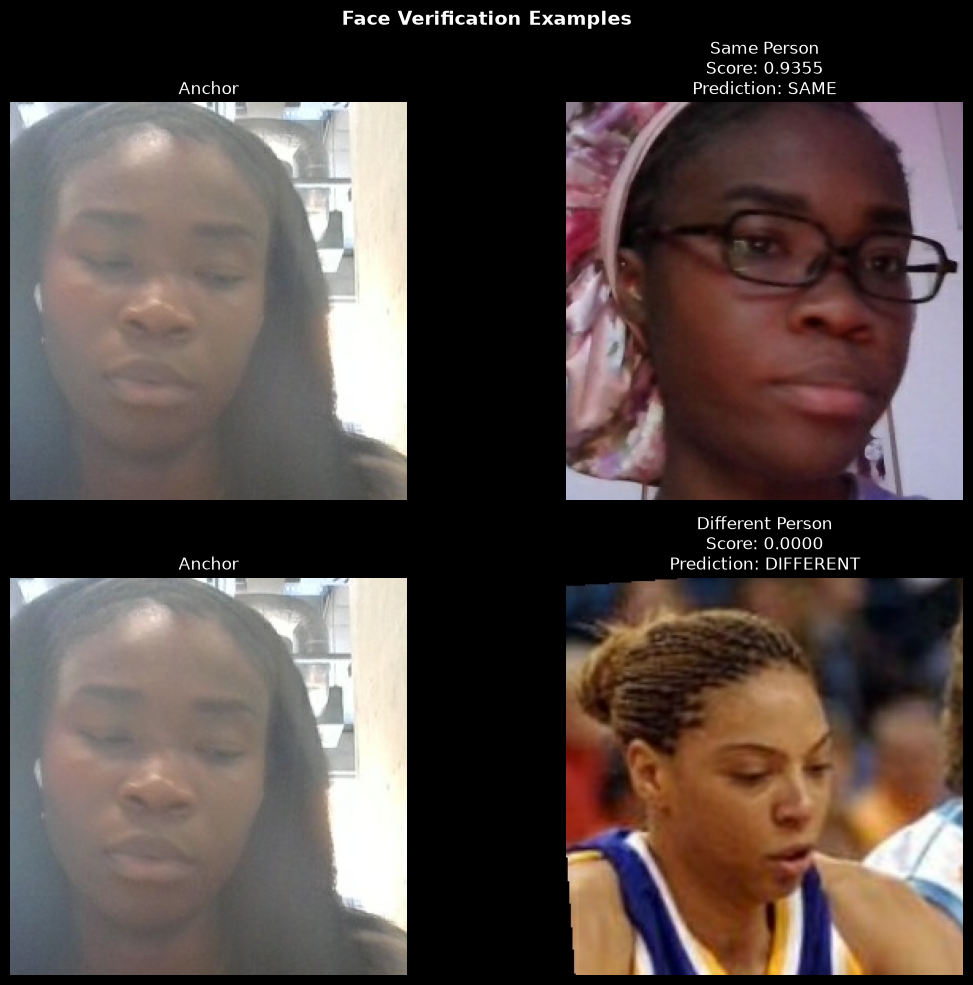


✓ Verification test completed successfully


In [27]:
# Alternative to Webcam: Test with saved images
if siamese_model is not None and anchor_paths:
    print("\nTesting with image examples (webcam alternative)...\n")

    # Load test images
    positive_paths = data.load_image_paths(str(config.POSITIVE_PATH))
    negative_paths = data.load_image_paths(str(config.NEGATIVE_PATH))

    # Select random pairs
    import random

    # Positive Pair (same person)
    anchor_idx = random.randint(0, min(200, len(anchor_paths)-1))
    positive_idx = random.randint(0, min(200, len(positive_paths)-1))

    anchor_img_pos = data.load_image(anchor_paths[anchor_idx]).numpy()
    positive_img = data.load_image(positive_paths[positive_idx]).numpy()

    anchor_img_pos_proc = data.preprocess_image(data.load_image(anchor_paths[anchor_idx])).numpy()
    positive_img_proc = data.preprocess_image(data.load_image(positive_paths[positive_idx])).numpy()

    # Negative Pair (different person)
    negative_idx = random.randint(0, min(200, len(negative_paths)-1))
    negative_img = data.load_image(negative_paths[negative_idx]).numpy()
    negative_img_proc = data.preprocess_image(data.load_image(negative_paths[negative_idx])).numpy()

    # Verify both pairs
    sim_positive, is_same_pos = utils.verify_faces(siamese_model, anchor_img_pos_proc, positive_img_proc)
    sim_negative, is_same_neg = utils.verify_faces(siamese_model, anchor_img_pos_proc, negative_img_proc)

    # Visualize results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Face Verification Examples', fontsize=14, fontweight='bold')

    # Positive Pair
    axes[0, 0].imshow(anchor_img_pos.astype(np.uint8))
    axes[0, 0].set_title('Anchor')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(positive_img.astype(np.uint8))
    axes[0, 1].set_title(f'Same Person\nScore: {sim_positive:.4f}\nPrediction: {"SAME" if is_same_pos else "DIFFERENT"}')
    axes[0, 1].axis('off')

    # Negative Pair
    axes[1, 0].imshow(anchor_img_pos.astype(np.uint8))
    axes[1, 0].set_title('Anchor')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(negative_img.astype(np.uint8))
    axes[1, 1].set_title(f'Different Person\nScore: {sim_negative:.4f}\nPrediction: {"SAME" if is_same_neg else "DIFFERENT"}')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    print("\n✓ Verification test completed successfully")

## 6.7 Summary

In [13]:
print("\n" + "="*80)
print("INFERENCE SUMMARY")
print("="*80)

print(f"\n✓ Facial Verification System:")
print(f"  - Model loaded and ready for use")
print(f"  - Verification Threshold: {config.VERIFICATION_THRESHOLD}")
print(f"  - Input Size: {config.IMG_SIZE}x{config.IMG_SIZE}")

print(f"\n✓ Live Verification (Webcam):")
print(f"  - Crop Region: {config.WEBCAM_FRAME_SIZE}x{config.WEBCAM_FRAME_SIZE}")
print(f"  - Offset: ({config.WEBCAM_OFFSET_X}, {config.WEBCAM_OFFSET_Y})")

print(f"\n✓ Ready for Deployment!")
print(f"\nNext Steps:")
print(f"  - Tune hyperparameters and retrain if necessary")
print(f"  - Deploy model to Unicluster for batch processing")
print(f"  - Develop web interface (optional)")

print("\n" + "="*80)
print("✓ Notebook 06 completed!")
print("="*80)


INFERENCE SUMMARY

✓ Facial Verification System:
  - Model loaded and ready for use
  - Verification Threshold: 0.25
  - Input Size: 100x100

✓ Live Verification (Webcam):
  - Crop Region: 250x250
  - Offset: (200, 120)

✓ Ready for Deployment!

Next Steps:
  - Tune hyperparameters and retrain if necessary
  - Deploy model to Unicluster for batch processing
  - Develop web interface (optional)

✓ Notebook 06 completed!
